Ingrese el número de iteraciones: 4
Ingrese los pesos iniciales separados por comas 0,0,0,0,0
Ingrese el valor de alfa: 0.000006


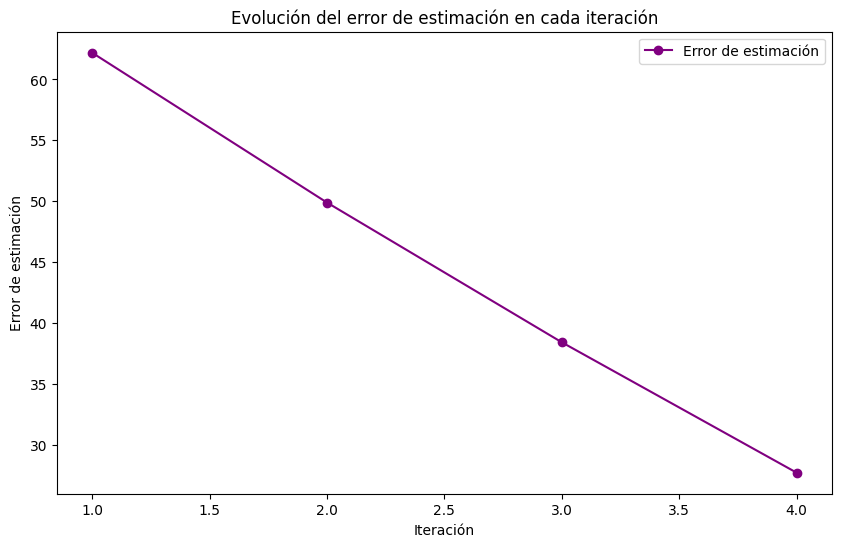

Peso (w)
Iteración 0: [ 0.0020532   0.00308328 -0.0585684   0.0698784   0.04016964]
Iteración 1: [ 0.00410623  0.00616604 -0.11358826  0.13371931  0.07918999]
Iteración 2: [ 0.00615908  0.00924827 -0.16527457  0.19204436  0.11709392]
Iteración 3: [ 0.00821177  0.01232999 -0.21382932  0.24533013  0.15391339]


y_test
[17.4 34.8 23.2]

Error de estimación
Iteración 0: 62.199130864
Iteración 1: 49.89302162435803
Iteración 2: 38.415122717705565
Iteración 3: 27.704098224303586

Predicciones de y
Iteración 0: [3.00262613 6.14736919 4.05087382]
Iteración 1: [ 5.80499764 11.87398673  7.827994  ]
Iteración 2: [ 8.4218645  17.21132733 11.35168545]
Iteración 3: [10.86682804 22.18839129 14.64068245]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Función de estimación de error
def estimationError(X, y, weights):
    predictions = X @ weights
    error = np.sum(np.abs(predictions - y))
    return error

def plotError(errors, iteraciones):
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, iteraciones + 1), errors, marker='o', color='purple', label='Error de estimación')
    plt.xlabel("Iteración")
    plt.ylabel("Error de estimación")
    plt.title("Evolución del error de estimación en cada iteración")
    plt.legend()
    plt.show()

def BGDMultivariable(file_path, iteraciones, initial_weights, alpha):
    # Cargar datos
    df = pd.read_csv(file_path)
    X = df[['x1', 'x2', 'x3', 'x4', 'x5']].values
    y = df['y'].values

    # Dividir en 70% entrenamiento y 30% prueba
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, train_size=0.7, shuffle=True, random_state=0)

    errors = []
    weights = []
    all_y_pred = []

    w = initial_weights
    for i in range(iteraciones):
        for i in range(5):
            x = X_train[:, i]
            suma = np.sum((w[i] * x - y_train) * x)
            w[i] = w[i] -2*alpha*suma
        weight = np.array(w)
        weights.append(weight)

        # Cálculo de error de estimación
        error = estimationError(X_test, y_test, w)
        errors.append(error)

        # Predicciones para los datos de prueba
        y_pred = X_test @ w
        all_y_pred.append(y_pred)  # Almacenar las predicciones de esta iteración

    plotError(errors, iteraciones)

    return weights, errors, y_test, all_y_pred

# Solicitar parámetros al usuario
file_path = 'Dataset_multivariable.csv'
num_iterations = int(input("Ingrese el número de iteraciones: "))
initial_weights = list(map(float, input("Ingrese los pesos iniciales separados por comas ").split(',')))
alpha = float(input("Ingrese el valor de alfa: "))

# Ejecutar el algoritmo
weights_history, error_history, y_test, y_pred = BGDMultivariable(file_path, num_iterations, initial_weights, alpha)

# Imprimir resultados
print("Peso (w)")
for i, w in enumerate(weights_history):
    print(f"Iteración {i}: {w}")

print('\n')
print("y_test")
print(y_test)
print("\nError de estimación")
for i, error in enumerate(error_history):
    print(f"Iteración {i}: {error}")

print("\nPredicciones de y")
for i, pred in enumerate(y_pred):
    print(f"Iteración {i}: {pred}")
